In [ ]:
from __future__ import annotations

import numpy as np
from dataclasses import dataclass, field


@dataclass
class DoubleRingParams:
    """Biophysical / connectivity parameters of the double-ring model."""

    n_neurons: int = 500
    tau: float = 80e-3

    J_0: float = -60
    J_1: float = 80
    phi: float = np.deg2rad(80)

    K_0: float = -5
    K_1: float = 80
    psi: float = np.deg2rad(50)

    I0: float = 2.0
    vel_gain: float = -0.00067


class DoubleRingHD:
    def __init__(self, params: DoubleRingParams | None = None):
        self.p = params or DoubleRingParams()
        N = self.p.n_neurons
        self.N = N
        self.theta = np.arange(N) * (2 * np.pi / N)
        W_LL = (
            self.p.J_0
            + self.p.J_1 * np.cos(self.theta - self.p.phi)
        ) / N

        W_RR = (
            self.p.J_0
            + self.p.J_1 * np.cos(self.theta + self.p.phi)
        ) / N

        W_LR = (
            self.p.K_0
            + self.p.K_1 * np.cos(self.theta + self.p.psi)
        ) / N

        W_RL = (
            self.p.K_0
            + self.p.K_1 * np.cos(self.theta - self.p.psi)
        ) / N

        self._fft_LL = np.fft.rfft(W_LL)
        self._fft_RR = np.fft.rfft(W_RR)
        self._fft_LR = np.fft.rfft(W_LR)
        self._fft_RL = np.fft.rfft(W_RL)

    def _circ_conv(self, kernel_fft: np.ndarray, x: np.ndarray) -> np.ndarray:
        return np.fft.irfft(kernel_fft * np.fft.rfft(x), n=self.N)

    @staticmethod
    def _relu(x: np.ndarray) -> np.ndarray:
        return np.maximum(x, 0.0)

    def vestibular_input(self, v: float) -> tuple[np.ndarray, np.ndarray]:
        I_L = self._relu(self.p.I0 - self.p.vel_gain * v)
        I_R = self._relu(self.p.I0 + self.p.vel_gain * v)
        return I_L, I_R

    def firing_rates(self, I_L, I_R):
        LL = self._circ_conv(self._fft_LL, self.s_L)
        RR = self._circ_conv(self._fft_RR, self.s_R)

        LR = self._circ_conv(self._fft_LR, self.s_R)
        RL = self._circ_conv(self._fft_RL, self.s_L)

        r_L = self._relu(LL + LR + I_L)
        r_R = self._relu(RR + RL + I_R)

        return r_L, r_R
    # def firing_rates(self, I_L, I_R):
    #     dtheta = self.theta[:, None] - self.theta[None, :]

    #     W_same = (
    #         self.p.J_0
    #         + self.p.J_1 * np.cos(dtheta + self.p.phi)
    #     ) / self.N

    #     W_diff = (
    #         self.p.K_0
    #         + self.p.K_1 * np.cos(dtheta + self.p.psi)
    #     ) / self.N

    #     h_L = W_same @ self.s_L + W_diff @ self.s_R + I_L
    #     h_R = W_same @ self.s_R + W_diff @ self.s_L + I_R

    #     return np.maximum(h_L, 0), np.maximum(h_R, 0)


    def step(self, dt: float, v: float) -> None:
        r_L, r_R = self.firing_rates(*self.vestibular_input(v))
        alpha = np.exp(-dt / self.p.tau)
        self.s_L = r_L + (self.s_L - r_L) * alpha
        self.s_R = r_R + (self.s_R - r_R) * alpha

    def set_bump(
        self,
        heading: float,
        amplitude: float = 1.0,
        width: float = 40.0,
    ) -> None:
        width_rad = np.deg2rad(width)

        d = (self.theta - heading + np.pi) % (2 * np.pi) - np.pi

        C = amplitude * np.cos(width_rad)

        bump = np.maximum(
            amplitude * np.cos(d) - C,
            0.0,
        )

        self.s_L = bump.copy()
        self.s_R = bump.copy()

    def decode_heading(self, v=0.0, which="both"):
        r_L, r_R = self.firing_rates(*self.vestibular_input(v))

        if which == "left":
            r = r_L
        elif which == "right":
            r = r_R
        else:
            r = r_L + r_R

        c = np.sum(r * np.cos(self.theta))
        s = np.sum(r * np.sin(self.theta))

        return float(np.arctan2(s, c) % (2 * np.pi))

    def simulate(self, velocity_trace: np.ndarray, dt: float, record_every: int = 1):
        n_steps = len(velocity_trace)
        t_out, heading_out = [], []
        sL_out, sR_out = [], []
        t = 0.0
        for i, v in enumerate(velocity_trace):
            self.step(dt, v)
            t += dt
            if i % record_every == 0:
                t_out.append(t)
                heading_out.append(self.decode_heading(which = "both"))
                sL_out.append(self.s_L.copy())
                sR_out.append(self.s_R.copy())
        return {
            "t": np.array(t_out),
            "heading": np.unwrap(np.array(heading_out)),
            "s_L": np.array(sL_out),
            "s_R": np.array(sR_out),
        }

In [2]:
import matplotlib.pyplot as plt

params = DoubleRingParams()
net = DoubleRingHD(params)

net.set_bump(heading=0.0, amplitude=5, width=20.0)
dt = 0.5e-3  # ms
settle_steps = 30000

for _ in range(settle_steps):
    net.step(dt, v=0.0)

/var/folders/_g/_c450dkj4j5djz911r45hnlc0000gn/T/ipykernel_3380/3366320592.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


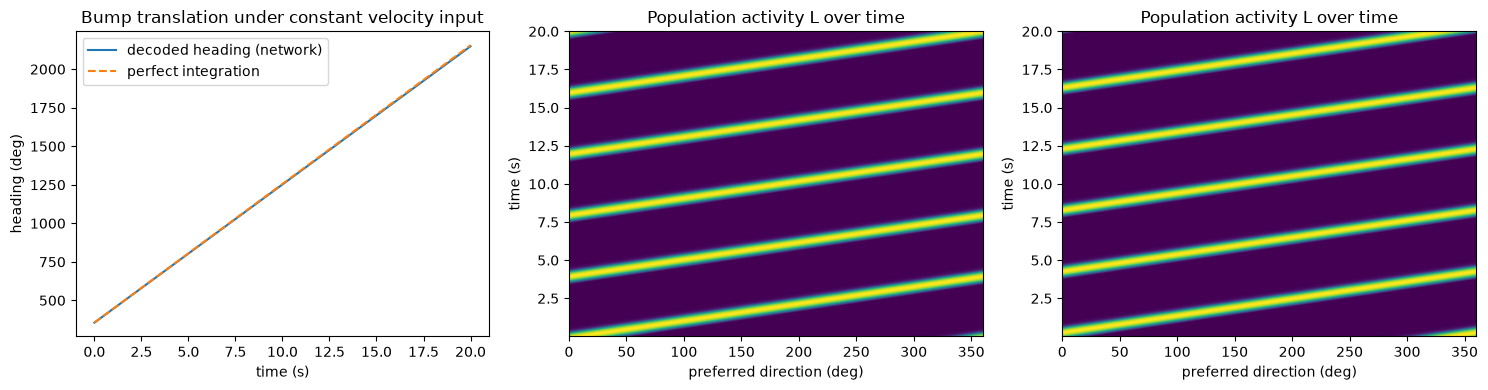

In [4]:
T = 20
n_steps = int(T / dt)
frequency_hz = 0.5
v_amplitude_deg_per_s = 90

time_s = np.arange(n_steps) * dt
velocity_trace = np.full_like(time_s,v_amplitude_deg_per_s) 

result = net.simulate(velocity_trace, dt=dt, record_every=1)

heading_deg = np.rad2deg(result["heading"])
t_s = result["t"]

# Expected heading if perfectly integrating v (deg/s) over time (s).
expected_deg = heading_deg[0] + np.cumsum(velocity_trace) * dt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t_s, heading_deg, label="decoded heading (network)")
axes[0].plot(t_s, expected_deg, "--", label=f"perfect integration")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("heading (deg)")
axes[0].legend()
axes[0].set_title("Bump translation under constant velocity input")

im = axes[1].imshow(
    result["s_L"],
    aspect="auto",
    origin="lower",
    extent=[0, 360, t_s[0], t_s[-1]],
    cmap="viridis",
)
axes[1].set_xlabel("preferred direction (deg)")
axes[1].set_ylabel("time (s)")
axes[1].set_title("Population activity L over time")
im = axes[2].imshow(
    result["s_R"],
    aspect="auto",
    origin="lower",
    extent=[0, 360, t_s[0], t_s[-1]],
    cmap="viridis",
)
axes[2].set_xlabel("preferred direction (deg)")
axes[2].set_ylabel("time (s)")
axes[2].set_title("Population activity L over time")


fig.tight_layout()
fig.show()